## 0. Setup

For Colab, run this cell once. Locally, the course virtual environment already provides the packages and the instructor can set `OXFORD_PET_ROOT` to the cached data directory. The preferred artifacts are a Session 4 checkpoint or saved validation predictions; environment variables `SESSION4_CHECKPOINT` and `SESSION4_PREDICTIONS` can point to them.

In [7]:
import os
import random
import urllib.request
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
from torchvision.models.segmentation import LRASPP_MobileNet_V3_Large_Weights, lraspp_mobilenet_v3_large


SEED = 17
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 2
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']
print('torch:', torch.__version__)

torch: 2.11.0+cpu


In [8]:
DATA_ROOT = Path(os.environ.get("OXFORD_PET_ROOT", "data"))
base = OxfordIIITPet(root=DATA_ROOT, split="trainval", target_types="segmentation", download=True)
permutation = torch.randperm(len(base), generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices, val_indices = permutation[:64], permutation[64:88]
assert len(train_indices) == 64 and len(val_indices) == 24
assert not set(train_indices).intersection(val_indices)
print(f"fixed split: train={len(train_indices)}, validation={len(val_indices)}, overlap=0")
print("first five train indices:", train_indices[:5])

fixed split: train=64, validation=24, overlap=0
first five train indices: [2479, 1638, 733, 859, 670]


In [9]:
def remap_trimap(raw_mask):
    raw = torch.as_tensor(np.asarray(raw_mask, dtype=np.uint8), dtype=torch.long)
    target = torch.full_like(raw, 255)
    target[raw == 1] = 1  # pet
    target[raw == 2] = 0  # background
    return target

def paired_transform(image, raw_mask):
    image = TF.resize(image, IMAGE_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True)
    raw_mask = TF.resize(raw_mask, IMAGE_SIZE, interpolation=InterpolationMode.NEAREST)
    image = TF.normalize(TF.to_tensor(image), mean=MEAN, std=STD)
    return image, remap_trimap(raw_mask)

class PetSubset(Dataset):
    def __init__(self, dataset, indices): self.dataset, self.indices = dataset, list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        image, trimap = self.dataset[self.indices[i]]
        return paired_transform(image, trimap)

train_loader = DataLoader(PetSubset(base, train_indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(PetSubset(base, val_indices), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, targets = next(iter(train_loader))
assert images.shape == (BATCH_SIZE, 3, 128, 128) and targets.shape == (BATCH_SIZE, 128, 128)
assert set(torch.unique(targets).tolist()) <= {0, 1, 255}
print("batch contract:", tuple(images.shape), tuple(targets.shape), torch.unique(targets).tolist())

batch contract: (16, 3, 128, 128) (16, 128, 128) [0, 1, 255]


## 1. Load the shared baseline (or a transparent fallback)

Preferred order: (1) a saved prediction `.npz`, then (2) a Session 4 LR-ASPP checkpoint. If neither is supplied, the notebook uses a **non-learned RGB heuristic** only so the class can practise evaluation and visualization. That fallback is explicitly not a Session 4 model result and must not be used as a performance claim.

In [12]:
checkpoint_path = ('session4_baseline.pt')

model = lraspp_mobilenet_v3_large(weights=None, weights_backbone=None, num_classes=2).eval()
checkpoint = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(checkpoint.get('model_state_dict', checkpoint))
with torch.inference_mode():
    logits = model(images)['out']
    probabilities = logits.softmax(dim=1)
predictions, pet_confidence = probabilities.argmax(dim=1), probabilities[:, 1]


assert predictions.shape == targets.shape == pet_confidence.shape
print('Session 4 checkpoint: session4_baseline.pt')

Session 4 checkpoint: session4_baseline.pt


## 2. Exercise E1 — report dataset-level metrics

Complete the confusion-matrix accumulation. Rows are true classes and columns are predicted classes. Accumulate all valid pixels across all 24 examples **before** calculating accuracy and IoU.

In [13]:
# TODO: return a 2x2 confusion matrix, excluding every target == IGNORE_INDEX
def confusion_from_dataset(targets, predictions, ignore_index=IGNORE_INDEX):
    confusion = torch.zeros((2, 2), dtype=torch.int64)

    valid = targets != ignore_index
    for truth, guess in zip(targets[valid].reshape(-1), predictions[valid].reshape(-1)):
        confusion[int(truth), int(guess)] += 1

    return confusion


def report_from_confusion(confusion):
    total = confusion.sum().item()
    accuracy = confusion.diag().sum().item() / total

    ious = []
    for class_id in range(2):
        true_positive = confusion[class_id, class_id].item()
        false_positive = confusion[:, class_id].sum().item() - true_positive
        false_negative = confusion[class_id, :].sum().item() - true_positive

        ious.append(
            true_positive / (true_positive + false_positive + false_negative)
        )

    return {
        "pixel_accuracy": accuracy,
        "background_iou": ious[0],
        "pet_iou": ious[1],
        "mean_iou": float(np.mean(ious)),
    }


confusion = confusion_from_dataset(targets, predictions)
report = report_from_confusion(confusion)

print("rows=true, columns=predicted\n", confusion)

for metric, value in report.items():
    print(f"{metric}: {value:.3f}")

assert confusion.sum().item() == int((targets != IGNORE_INDEX).sum())
assert all(np.isfinite(value) for value in report.values())


rows=true, columns=predicted
 tensor([[120523,  24767],
        [  1702,  84993]])
pixel_accuracy: 0.886
background_iou: 0.820
pet_iou: 0.763
mean_iou: 0.791


The value above is a dataset report: every valid pixel gets one vote. We do **not** average 24 per-image IoUs, because that would weight a tiny pet and a large pet equally.

## 3. Choose three cases by rule

Rule: select the lowest pet-IoU image, then the median and highest pet-IoU images from the remaining examples. This gives one difficult case and two contrasts without cherry-picking by appearance.

In [14]:
def pet_iou(target, prediction):
    valid = target != IGNORE_INDEX
    truth_pet, predicted_pet = (target == 1) & valid, (prediction == 1) & valid
    union = (truth_pet | predicted_pet).sum().item()
    return (truth_pet & predicted_pet).sum().item() / union if union else np.nan

per_image_iou = np.array([pet_iou(target, prediction) for target, prediction in zip(targets, predictions)])
ordered = np.argsort(np.nan_to_num(per_image_iou, nan=2.0))
low_index = int(ordered[0])
remaining = [int(index) for index in ordered if int(index) != low_index]
chosen_indices = [low_index, remaining[len(remaining) // 2], remaining[-1]]
for index in chosen_indices:
    print(f'pet IoU = {per_image_iou[index]:.3f}')
assert len(set(chosen_indices)) == 3

pet IoU = 0.298
pet IoU = 0.771
pet IoU = 0.957


## 4. Exercise E2 — make aligned visual evidence

Complete the plotting function, then call it for the lowest-pet-IoU case. All five panels use the same `128 × 128` pixel coordinates: original image, ground truth, prediction, pet confidence, and an alpha overlay. Gray ground-truth pixels are ignored borders, not a third class.

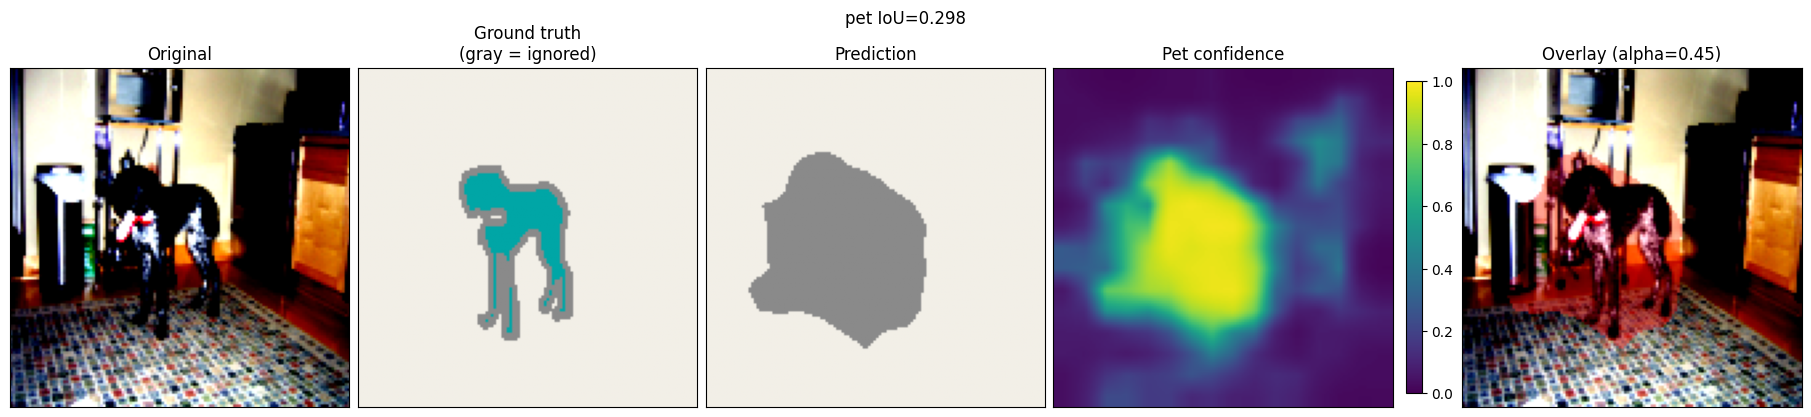

In [15]:
# TODO: complete the five-panel visualization; do not resize panels independently
mask_cmap = ListedColormap(['#f2efe7', '#00a6a6', '#8a8a8a'])

def display_target(target):
    shown = target.clone().numpy()
    shown[shown == IGNORE_INDEX] = 2
    return shown

def show_five_panels(index, alpha=0.45):
    image = images[index].permute(1, 2, 0).numpy()
    target = display_target(targets[index])
    prediction = predictions[index].numpy()
    confidence = pet_confidence[index].numpy()

    overlay = image.copy()
    overlay[prediction == 1] = (
        (1 - alpha) * overlay[prediction == 1]
        + alpha * np.array([1.0, 0.1, 0.1])
    )

    fig, axes = plt.subplots(
        1, 5, figsize=(18, 4), constrained_layout=True
    )

    panels = [
        (image, 'Original', None),
        (target, 'Ground truth\n(gray = ignored)', mask_cmap),
        (prediction, 'Prediction', mask_cmap),
        (confidence, 'Pet confidence', 'viridis'),
        (overlay, f'Overlay (alpha={alpha})', None)
    ]

    for axis, (panel, title, cmap) in zip(axes, panels):
        artist = axis.imshow(
            panel,
            cmap=cmap,
            vmin=0 if title == 'Pet confidence' else None,
            vmax=1 if title == 'Pet confidence' else None
        )

        axis.set_title(title)
        axis.set_xlim(-0.5, IMAGE_SIZE[0] - 0.5)
        axis.set_ylim(IMAGE_SIZE[0] - 0.5, -0.5)
        axis.set_xticks([])
        axis.set_yticks([])

        if title == 'Pet confidence':
            fig.colorbar(
                artist,
                ax=axis,
                fraction=0.046,
                pad=0.04
            )

    fig.suptitle(f'pet IoU={per_image_iou[index]:.3f}', y=1.04)
    plt.show()

show_five_panels(chosen_indices[0])

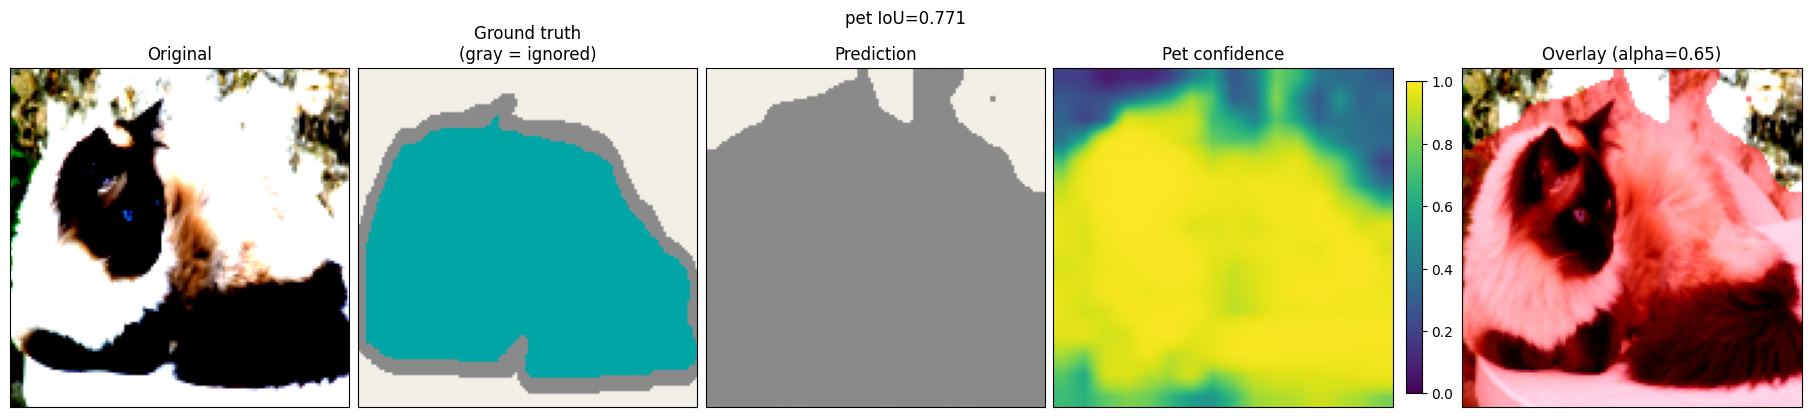

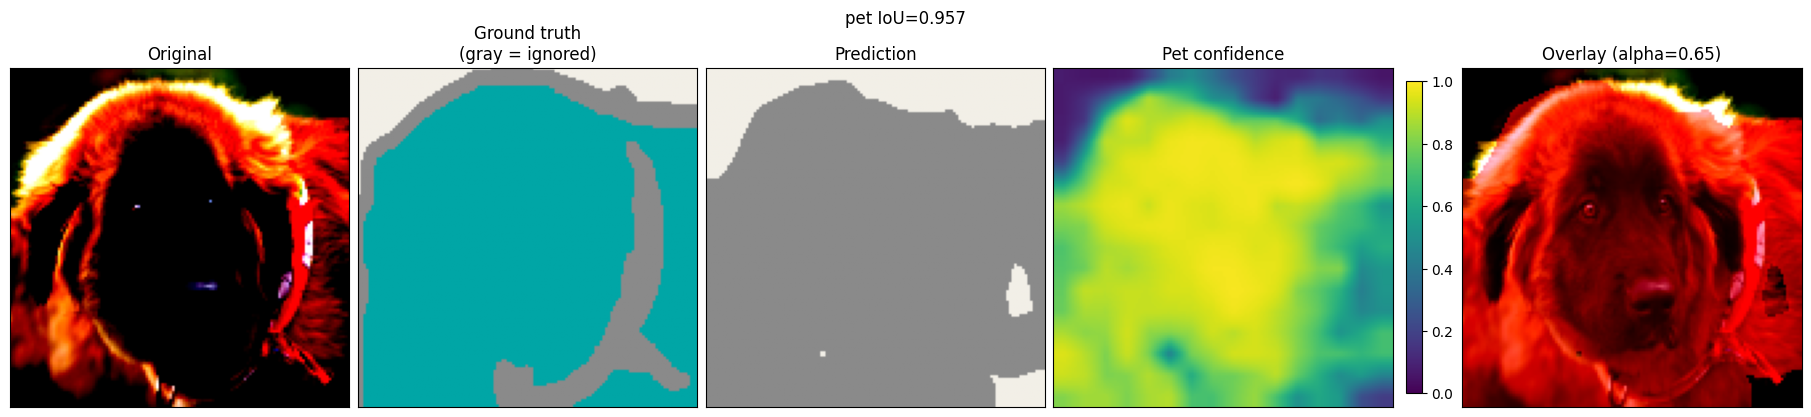

In [16]:
# Compare the other two rule-selected cases. Changing alpha only changes the display.
show_five_panels(chosen_indices[1], alpha=0.65)
show_five_panels(chosen_indices[2], alpha=0.65)